In [ ]:
import os

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Download and load the source dataset
path = kagglehub.dataset_download("sid321axn/gold-price-prediction-dataset")
df = pd.read_csv(os.path.join(path, "FINAL_USO.csv"))

# Select relevant fields and apply readable column names
df = df[["Date", "Adj Close", "SP_Ajclose", "EU_Price", "USO_Adj Close", "SF_Price"]]
df_clean = df.copy()
df_clean.columns = ["Date", "Gold", "SP500", "Euro", "Oil", "Silver"]
df_clean = df_clean.dropna()

# Build a quarter category from the date for seasonal analysis
df_clean["Date"] = pd.to_datetime(df_clean["Date"])
df_clean["Quarter"] = df_clean["Date"].dt.quarter.astype("category")

# Draw a reproducible sample for modeling and diagnostics
sample_indices = df_clean.sample(n=1000, random_state=555).index
sample_data = df_clean.loc[sample_indices]

print(sample_data.head())
sample_data.to_csv("sample_data.csv", index=False)

#Get counts grouped by year
years = df_clean["Date"].dt.year
print(years.value_counts())

           Date        Gold       SP500    Euro        Oil  Silver Quarter
1376 2017-08-16  121.870003  239.913834  1.1770   9.570000   38863       3
1107 2016-07-15  126.839996  205.511993  1.1036  10.990000   47275       3
296  2013-03-01  152.440002  135.032669  1.3022  32.740002   53711       1
664  2014-10-06  116.029999  180.249847  1.2654  34.040001   38488       4
1314 2017-05-17  119.790001  227.998383  1.1159  10.190000   39199       2
Date
2015    250
2016    248
2017    248
2018    248
2012    245
2014    245
2013    223
2011     11
Name: count, dtype: int64


In [93]:
# Define predictors (X) and response (Y)
X = sample_data[["SP500", "Euro", "Oil", "Silver"]]
Y = sample_data["Gold"]

# Standardize predictors and add an intercept term for OLS
X_mean = X.mean()
X_std = X.std()
X_scaled = (X - X_mean) / X_std
X_scaled = sm.add_constant(X_scaled)

# Quick validation of scaling behavior
print("Standardized Predictor Summary:")
print(X_scaled.describe())

Standardized Predictor Summary:
        const         SP500          Euro           Oil        Silver
count  1000.0  1.000000e+03  1.000000e+03  1.000000e+03  1.000000e+03
mean      1.0  3.161915e-16 -1.296740e-16 -1.083578e-16  3.943512e-16
std       0.0  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00
min       1.0 -1.763488e+00 -1.690362e+00 -1.283494e+00 -1.335142e+00
25%       1.0 -8.164626e-01 -8.924305e-01 -9.758816e-01 -7.083856e-01
50%       1.0  9.455081e-03 -1.952641e-01 -3.786743e-01 -3.584608e-01
75%       1.0  7.731935e-01  9.464108e-01  1.054360e+00  4.777663e-01
max       1.0  2.087133e+00  1.806142e+00  1.686283e+00  2.757071e+00


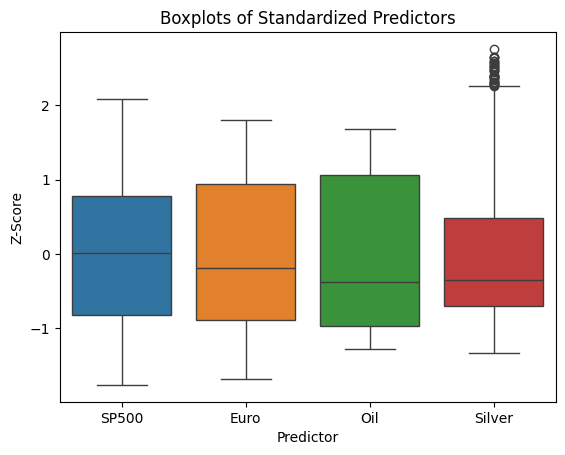

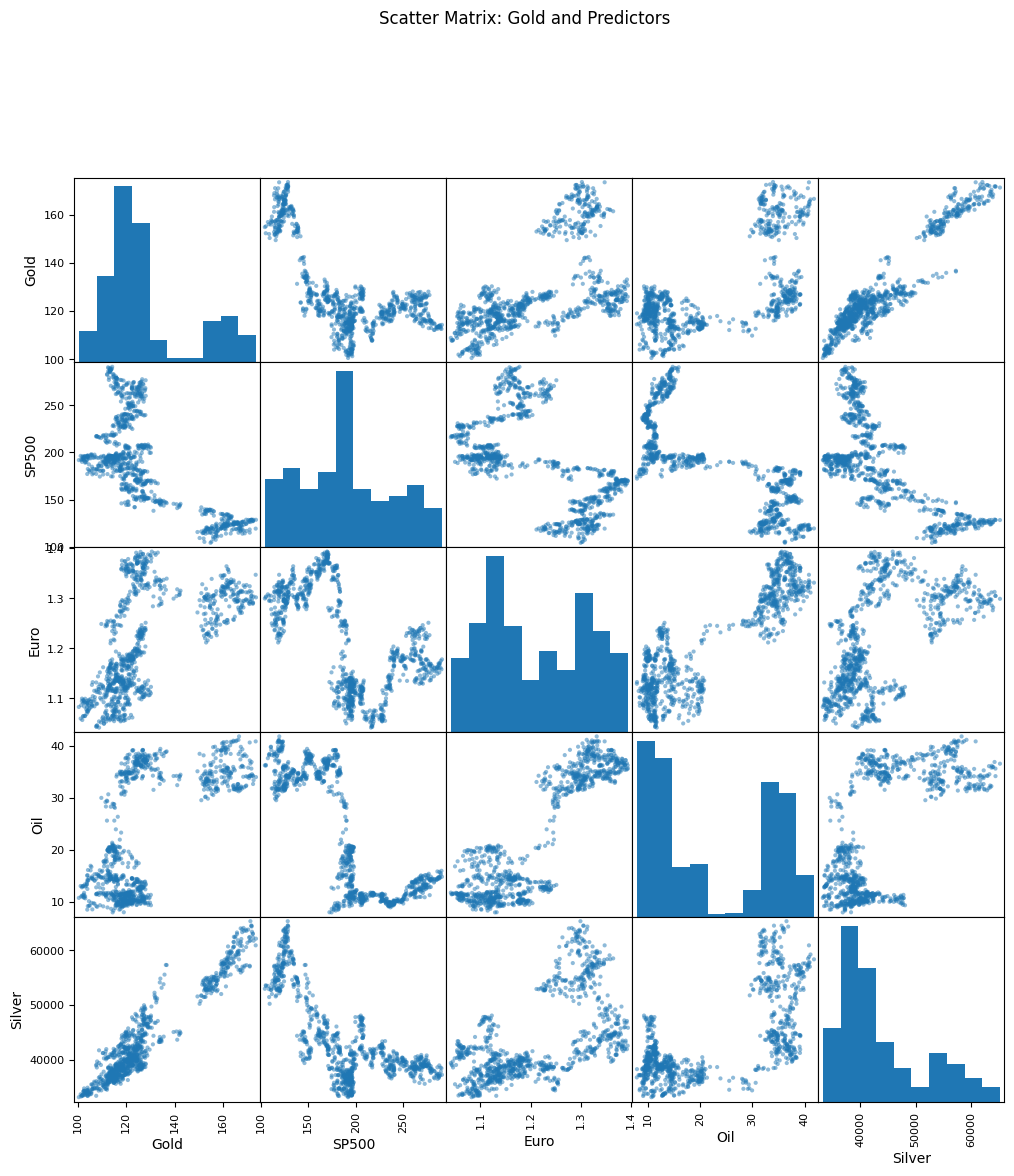

Correlation Matrix:
            Gold     SP500      Euro       Oil    Silver
Gold    1.000000 -0.678884  0.586117  0.638480  0.951659
SP500  -0.678884  1.000000 -0.570132 -0.793016 -0.715193
Euro    0.586117 -0.570132  1.000000  0.885847  0.592556
Oil     0.638480 -0.793016  0.885847  1.000000  0.669904
Silver  0.951659 -0.715193  0.592556  0.669904  1.000000


In [94]:
# Distribution check: standardized predictors should be centered near zero
ax = sns.boxplot(data=X_scaled[["SP500", "Euro", "Oil", "Silver"]])
ax.set_title("Boxplots of Standardized Predictors")
ax.set_xlabel("Predictor")
ax.set_ylabel("Z-Score")
plt.show()

# Pairwise relationships and correlation structure among numeric variables
scatter_data = sample_data[["Gold", "SP500", "Euro", "Oil", "Silver"]]
pd.plotting.scatter_matrix(scatter_data, figsize=(12, 12))
plt.suptitle("Scatter Matrix: Gold and Predictors", y=1.02)
plt.show()

print("Correlation Matrix:")
print(scatter_data.select_dtypes(include="number").corr())

In [95]:
# Baseline OLS model using all standardized predictors
model = sm.OLS(Y, X_scaled).fit()
print(model.summary())

# Compare observed F-statistic to the critical value at alpha = 0.05
f_critical = stats.f.ppf(0.95, dfn=4, dfd=996)
print(f"\nF-critical (alpha=0.05, df1=4, df2=996): {f_critical:.2f}")

# Individual predictor significance
print("\nP-values by predictor:")
print(model.pvalues)

                            OLS Regression Results                            
Dep. Variable:                   Gold   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.908
Method:                 Least Squares   F-statistic:                     2464.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:23:22   Log-Likelihood:                -3123.0
No. Observations:                1000   AIC:                             6256.
Df Residuals:                     995   BIC:                             6281.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        128.0787      0.174    735.067      0.0

In [ ]:
# Reduced OLS model after removing Silver
new_model = sm.OLS(Y, X_scaled[["const", "SP500", "Euro", "Oil"]]).fit()
print(new_model.summary())

# Compare observed F-statistic to the critical value at alpha = 0.05
f_critical = stats.f.ppf(0.95, dfn=3, dfd=996)
print(f"\nF-critical (alpha=0.05, df1=3, df2=996): {f_critical:.2f}")

# Individual predictor significance
print("\nP-values by predictor:")
print(new_model.pvalues)

                            OLS Regression Results                            
Dep. Variable:                   Gold   R-squared:                       0.528
Model:                            OLS   Adj. R-squared:                  0.527
Method:                 Least Squares   F-statistic:                     371.3
Date:                Sat, 18 Apr 2026   Prob (F-statistic):          8.04e-162
Time:                        22:15:52   Log-Likelihood:                -3942.2
No. Observations:                1000   AIC:                             7892.
Df Residuals:                     996   BIC:                             7912.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        128.0787      0.395    324.169      0.0

Influential observations (Cook's D > 0.0040):
 observation  cooks_distance  dfbeta_SP500  dfbeta_Euro  dfbeta_Oil
         165        0.006461      0.129733    -0.049306    0.112808
         202        0.004109      0.096218    -0.023979    0.077675
         208        0.004102      0.108408    -0.064706    0.106709
         314        0.004150      0.020606    -0.089221    0.047901
         347        0.004910      0.115440    -0.084121    0.121475
         355        0.004807      0.115420    -0.072478    0.114063
         501        0.004083      0.094845    -0.023475    0.077014
         578        0.005282      0.123433    -0.084191    0.127574
         598        0.004971      0.112026    -0.035900    0.093534
         751        0.004085      0.104825    -0.062036    0.104365
         914        0.004450      0.017675    -0.089554    0.045388

Tab-separated copy/paste table:
observation	cooks_distance	dfbeta_SP500	dfbeta_Euro	dfbeta_Oil
165	0.006460672095387502	0.129733060937593

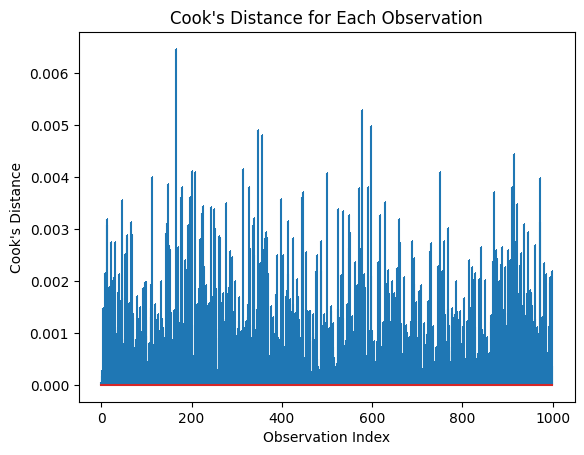

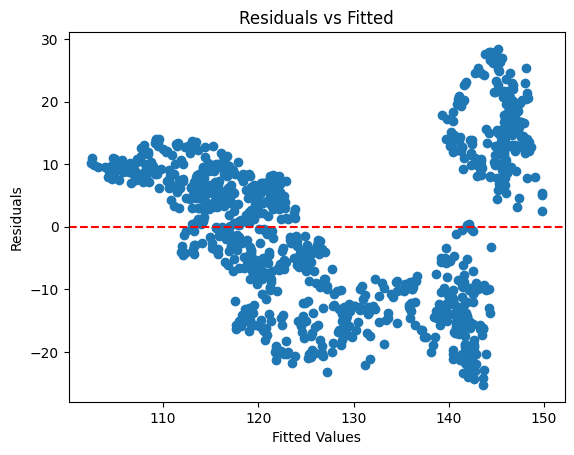

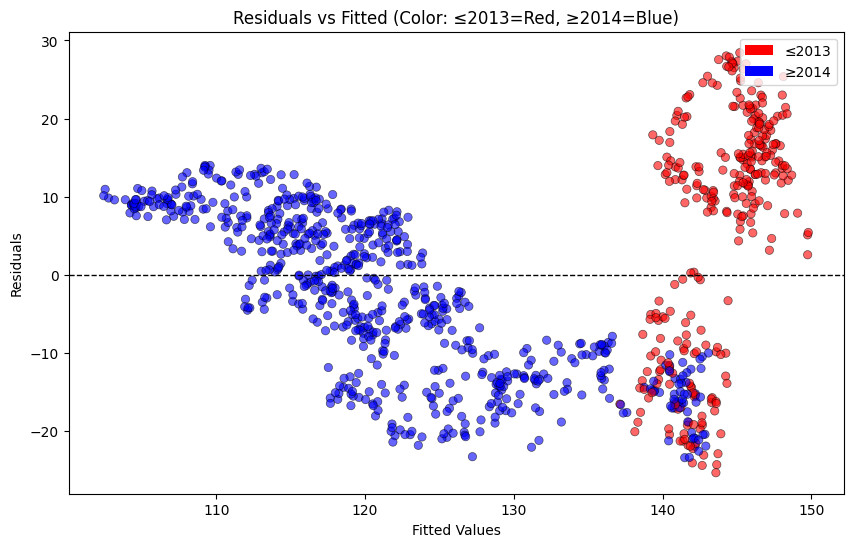

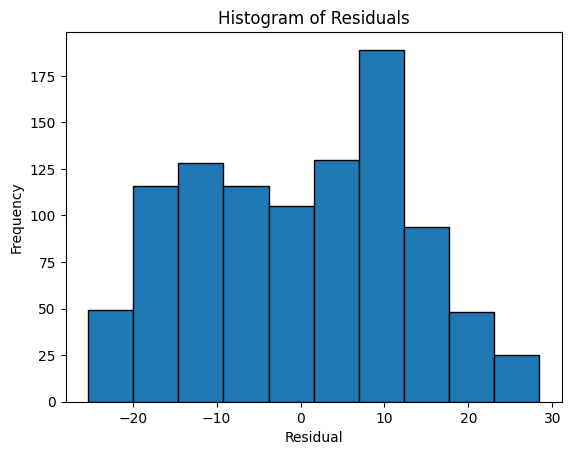

In [ ]:
# Residual diagnostics for the reduced model
residuals = new_model.resid
fitted_vals = new_model.fittedvalues

# Cook's distance: identify influential observations
influence = new_model.get_influence()
cooks_d = influence.cooks_distance[0]
dfbetas = influence.dfbetas
n = len(sample_data)
threshold = 4 / n

# Identify points above the 4/n rule-of-thumb threshold
influential_rows = []
for i, value in enumerate(cooks_d):
    if value > threshold:
        influential_rows.append(
            {
                "observation": i,
                "cooks_distance": value,
                "dfbeta_SP500": dfbetas[i, 1],
                "dfbeta_Euro": dfbetas[i, 2],
                "dfbeta_Oil": dfbetas[i, 3],
            }
        )

if influential_rows:
    influential_table = pd.DataFrame(influential_rows)
    print(f"Influential observations (Cook's D > {threshold:.4f}):")
    print(influential_table.to_string(index=False))

else:
    print(f"No influential observations found with Cook's D > {threshold:.4f}.")

# Plot Cook's distance to visually identify influential points
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance for Each Observation")
plt.show()

# Residuals vs fitted values: assess linearity and constant variance
plt.scatter(fitted_vals, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# Residuals vs fitted, color-coded by year: pre-2014 (red) vs post-2013 (blue)
years = sample_data["Date"].dt.year.reset_index(drop=True)
colors = ['red' if year <= 2013 else 'blue' for year in years]

plt.figure(figsize=(10, 6))
plt.scatter(fitted_vals, residuals, c=colors, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Color: ≤2013=Red, ≥2014=Blue)")

# Create manual legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='≤2013'), Patch(facecolor='blue', label='≥2014')]
plt.legend(handles=legend_elements, loc='upper right')
plt.show()

# Residual histogram: quick check of residual distribution shape
plt.hist(residuals, bins=10, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()


Observations per Quarter:
Quarter
1    235
2    254
3    251
4    260
Name: count, dtype: int64


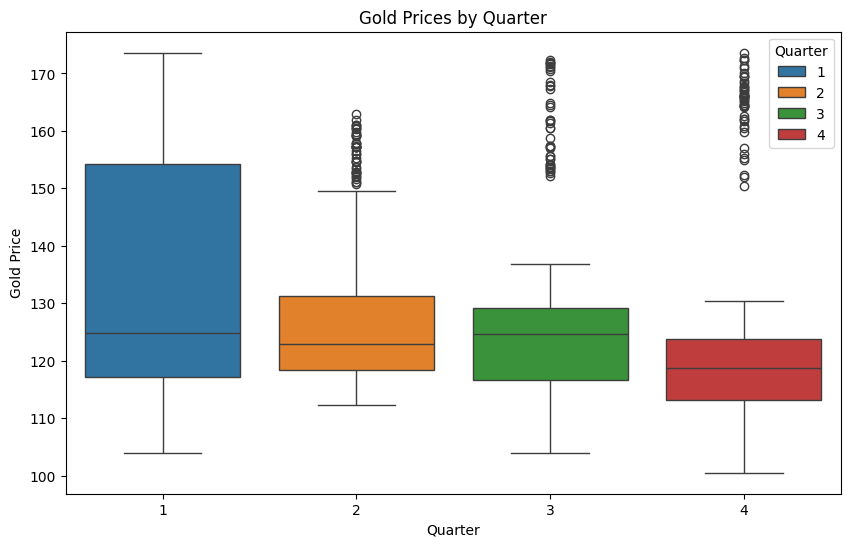

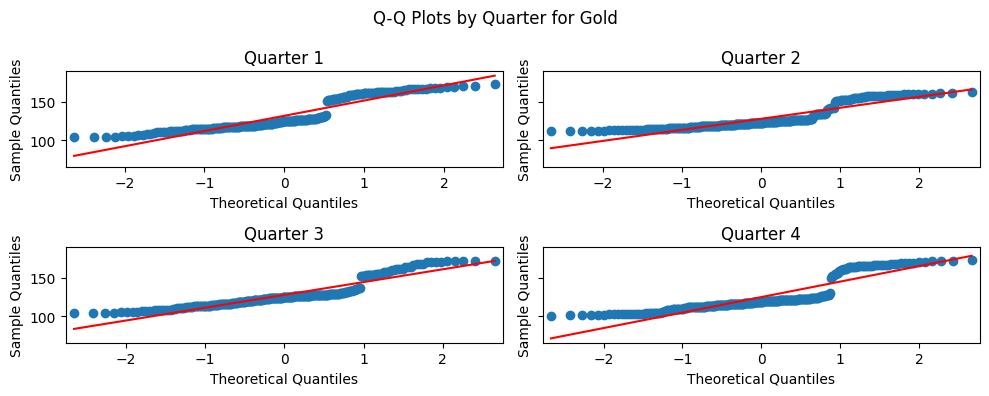

Standard Deviation for Quarter 1: 19.96
Standard Deviation for Quarter 2: 14.48
Standard Deviation for Quarter 3: 16.79
Standard Deviation for Quarter 4: 20.29


In [ ]:
# Get group counts by quarter
group_counts = sample_data["Quarter"].value_counts().sort_index()
print("Observations per Quarter:")
print(group_counts)

groups = sample_data["Quarter"].cat.categories

# Boxplot: distribution of Gold by quarter
plt.figure(figsize=(10, 6))
sns.boxplot(x="Quarter", y="Gold", data=sample_data, hue="Quarter", dodge=False)
plt.title("Gold Prices by Quarter")
plt.ylabel("Gold Price")
plt.xlabel("Quarter")
plt.savefig("gold_boxplot.png")
plt.show()

# Q-Q plots by quarter to visually assess normality within each group
fig, axes = plt.subplots(2, 2, figsize=(10, 4), sharey=True)
for ax, grp in zip(axes.flatten(), groups):
    sm.qqplot(data=sample_data[sample_data["Quarter"] == grp]["Gold"], line="s", ax=ax)
    ax.set_title(f"Quarter {grp}")
fig.suptitle("Q-Q Plots by Quarter for Gold")
fig.tight_layout()
fig.savefig("qq_plots_gold.png")
plt.show()

# Standard deviation by quarter for dispersion comparison
for grp in groups:
    std = sample_data[sample_data["Quarter"] == grp]["Gold"].std()
    print(f"Standard Deviation for Quarter {grp}: {std:.2f}")

In [108]:
# One-way ANOVA: test whether mean Gold price differs by calendar quarter
anova_model = smf.ols('Gold ~ C(Quarter)', data=sample_data).fit()
anova_results = anova_lm(anova_model, typ=2)
print('ANOVA Results (Type II):')
print(anova_results)

# Critical F-value at alpha = 0.05 for comparison with observed F statistic
df_between = anova_results['df'].iloc[0]
df_within = anova_results['df'].iloc[1]
critical_f = stats.f.ppf(0.95, df_between, df_within)
print(f"\nCritical F (alpha=0.05): {critical_f:.4f}")

# Post-hoc Tukey HSD: identify which quarter pairs differ significantly
tukey_results = pairwise_tukeyhsd(
    endog=sample_data['Gold'],
    groups=sample_data['Quarter'],
    alpha=0.05,
)
print('\nTukey HSD Pairwise Comparisons:')
print(tukey_results)


ANOVA Results (Type II):
                   sum_sq     df         F    PR(>F)
C(Quarter)    6016.981869    3.0  6.177806  0.000369
Residual    323357.163051  996.0       NaN       NaN

Critical F (alpha=0.05): 2.6138

Tukey HSD Pairwise Comparisons:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2  -3.9568 0.0729  -8.1536    0.24  False
     1      3  -4.0731  0.062  -8.2819  0.1357  False
     1      4  -6.9623 0.0001 -11.1358 -2.7888   True
     2      3  -0.1163 0.9999   -4.243  4.0104  False
     2      4  -3.0055 0.2326  -7.0961  1.0852  False
     3      4  -2.8892 0.2682  -6.9922  1.2138  False
-----------------------------------------------------


Influential observations (Cook's D > 0.0040):
 observation  cooks_distance  dfbeta_SP500   dfbeta_Euro    dfbeta_Oil
           8        0.005041  1.470846e-13  2.013569e-14  9.804604e-02
          12        0.005952  1.629895e-13  3.049016e-14  1.065902e-01
          13        0.006019  2.112974e-13  1.081692e-01 -3.069139e-13
          22        0.004149 -9.298574e-02 -9.271983e-02 -9.350568e-02
          28        0.004753  1.418785e-14 -4.788308e-14  9.519264e-02
          31        0.004303 -9.469832e-02 -9.442752e-02 -9.522784e-02
          45        0.006722 -9.286228e-15 -8.115831e-14  1.133192e-01
          53        0.004718 -9.917922e-02 -9.889561e-02 -9.973379e-02
          57        0.004244  2.269277e-13  9.075312e-02 -3.088334e-13
          65        0.005954 -6.742729e-14  1.075772e-01  8.345147e-14
          96        0.004668  1.836153e-13  5.168965e-14  9.432968e-02
         143        0.005061 -1.027395e-01 -1.024457e-01 -1.033140e-01
         146        0.006416  1

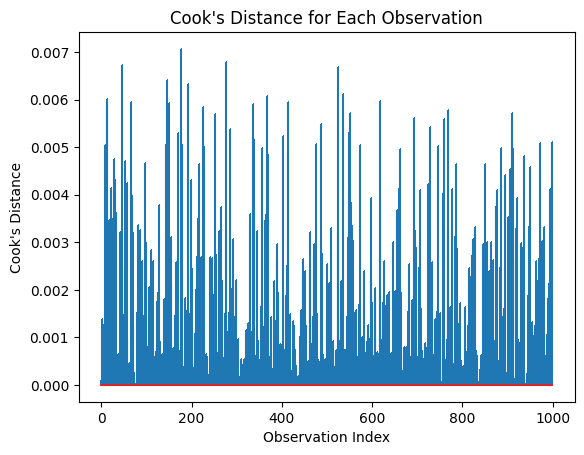

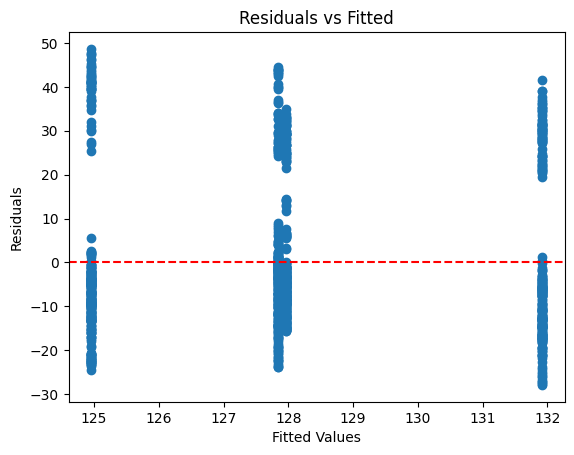

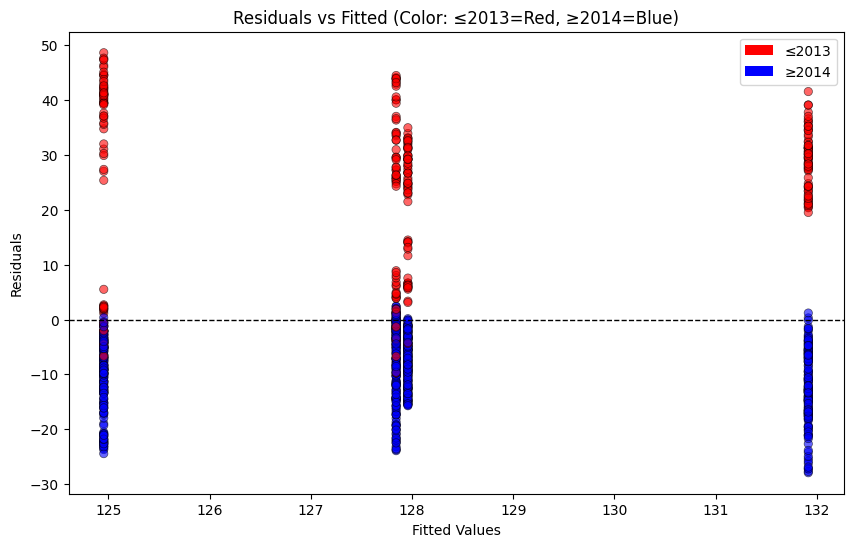

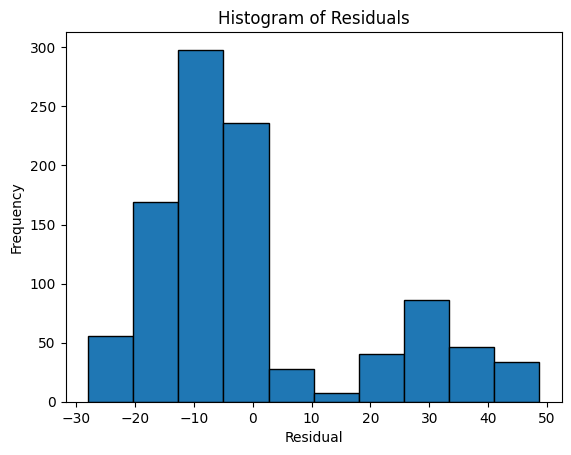

In [ ]:
# Residual diagnostics for the ANOVA model
anova_residuals = anova_model.resid
anova_fitted_vals = anova_model.fittedvalues

# Cook's distance: identify influential observations
influence_anova = anova_model.get_influence()
cooks_d = influence_anova.cooks_distance[0]
dfbetas = influence_anova.dfbetas
n = len(sample_data)
threshold = 4 / n

# Identify points above the 4/n rule-of-thumb threshold
influential_rows = []
for i, value in enumerate(cooks_d):
    if value > threshold:
        influential_rows.append(
            {
                "observation": i,
                "cooks_distance": value,
                "dfbeta_SP500": dfbetas[i, 1],
                "dfbeta_Euro": dfbetas[i, 2],
                "dfbeta_Oil": dfbetas[i, 3],
            }
        )

if influential_rows:
    influential_table = pd.DataFrame(influential_rows)
    print(f"Influential observations (Cook's D > {threshold:.4f}):")
    print(influential_table.to_string(index=False))

    print("\nTab-separated copy/paste table:")
    print(influential_table.to_csv(index=False, sep="\t"))
else:
    print(f"No influential observations found with Cook's D > {threshold:.4f}.")

# Plot Cook's distance to visually identify influential points
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance for Each Observation")
plt.show()

# Residuals vs fitted values: assess linearity and constant variance
plt.scatter(anova_fitted_vals, anova_residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# Residuals vs fitted, color-coded by year: pre-2014 (red) vs post-2013 (blue)
years = sample_data["Date"].dt.year.reset_index(drop=True)
colors = ['red' if year <= 2013 else 'blue' for year in years]

plt.figure(figsize=(10, 6))
plt.scatter(anova_fitted_vals, anova_residuals, c=colors, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Color: ≤2013=Red, ≥2014=Blue)")

# Create manual legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='≤2013'), Patch(facecolor='blue', label='≥2014')]
plt.legend(handles=legend_elements, loc='upper right')
plt.show()

# Residual histogram: quick check of residual distribution shape
plt.hist(anova_residuals, bins=10, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()
